# Week 2 — Customer Segmentation
## E-commerce Marketing Analysis · Online Retail (UK, 2010-2011)

**Analyst:** Capstone Student  
**Supervisor:** Mohamed Adnan  
**Dataset:** Online Retail CSV · 133,907 transactions  
**Techniques:** RFM Analysis + K-Means Clustering + ANOVA + R²  
**Tools:** Python · pandas · scikit-learn · scipy · matplotlib · seaborn

---

### Business Context

RetailGlobe Ltd. is a UK-based online retailer that sells giftware to wholesale buyers and direct consumers across 40+ countries. Marketing Director **Emma Watson** needs to answer three questions for a board meeting in 7 days:

1. **Who are our VIP customers that we should never lose?**
2. **Which customers are at risk of leaving us?**
3. **How should we segment our base for different marketing campaigns?**

This notebook delivers a complete data-driven answer using RFM analysis and K-Means clustering.

---

### Methodology Overview

The raw dataset of 133,907 transactions was cleaned by removing rows with missing customer IDs, negative quantities (returns), and exact duplicates — retaining 124,516 rows across 3,994 identifiable customers. For each customer, three behavioural metrics were computed: **Recency** (days since last purchase), **Frequency** (number of unique orders), and **Monetary value** (total spend in £), collectively known as RFM. These features were standardised using `StandardScaler` before clustering, since K-Means is sensitive to scale differences between variables. The optimal number of clusters (K=4) was selected using the Elbow Method and Silhouette Score, then **ANOVA** (Analysis of Variance) was applied to statistically confirm that the four segments are genuinely different from each other — not just visually distinct. Finally, **R²** (the ratio of between-cluster variance to total variance) was calculated to quantify how much of the overall variation in customer behaviour the segmentation model explains, providing an objective measure of cluster quality.

---

### Known Biases in This Dataset

Before any analysis, it is important to acknowledge the structural biases present in this data. Ignoring them would lead to overconfident conclusions.

| Bias | Description | Impact |
|------|-------------|--------|
| **Geographic concentration bias** | 87.9% of transactions are from the UK | Segment profiles reflect UK buying behaviour; findings should not be generalised to international customers without validation |
| **Survivorship bias** | Only customers who completed a purchase are visible | We know nothing about visitors who browsed but didn't buy, or customers who churned before this period |
| **Wholesale / retail mixing bias** | The dataset contains both B2B wholesale buyers and B2C individual consumers | A wholesale buyer placing one large annual order looks "At-Risk" in the model — they are not; mixing these two populations distorts the clusters |
| **Temporal / recency bias** | Data covers only 13 months (Dec 2010 – Dec 2011) | Customers who were loyal in prior years but paused will appear Dormant; the Q4 Christmas spike inflates Monetary scores for seasonal-only buyers |
| **Missing customer bias** | 6,697 rows (5%) had no CustomerID and were dropped | If missing IDs are systematically from a certain country or product category, our customer population is not fully representative |

> **Implication:** These biases mean our segmentation is most reliable for UK-based, repeat-purchase customers. Any marketing decisions targeting international customers or new customers should be treated as hypotheses to test, not confirmed findings.

---

### Table of Contents
1. Environment Setup  
2. Bias & Data Quality Considerations  
3. Phase 1 — Data Engineering & Cleaning  
4. Phase 2 — Exploratory Data Analysis (EDA)  
5. Phase 3 — Customer Segmentation (RFM + K-Means)  
6. Phase 4 — Export for Power BI  
7. Phase 5 — Executive Summary

## 0. Environment Setup

In [3]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Utilities
import datetime as dt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
PALETTE = sns.color_palette("viridis", 6)

print("Setup complete")

Setup complete


---
## 2. Bias & Data Quality Considerations

Before writing a single line of analysis code, we must acknowledge what is wrong with — or missing from — this dataset. This is not a formality; it directly affects which conclusions we can and cannot draw.

### 2.1 Geographic Concentration Bias

This dataset is **not a global dataset** — it is a UK dataset with some international transactions attached. With 87.9% of rows from the UK, every aggregate pattern we find (average order value, peak season, popular products) is really a UK pattern. This is structurally identical to the "US Bias" problem seen in global machine learning datasets, where one country dominates and its patterns get treated as universal truths.

**What this means in practice:** If Emma uses our segment findings to design a campaign for German customers, she is applying UK-derived insights to a market with different culture, seasonality, and competitive landscape. The four clusters we identify are UK clusters first.

### 2.2 Survivorship Bias

We only observe customers who **completed at least one transaction**. We have no data on:
- Visitors who browsed the website and left without buying
- Former customers who churned before December 2010
- Prospects who received a marketing email and never converted

Our "At-Risk" segment is therefore only the customers we *know about* who are drifting away. The true at-risk population — including those who left before our data begins — is likely larger.

### 2.3 Wholesale vs. Retail Mixing Bias

RetailGlobe sells to two fundamentally different buyer types:
- **Wholesale buyers** (small businesses): buy in bulk, infrequently, in large single orders
- **Direct consumers**: buy smaller quantities, potentially more frequently

These buyers have different motivations, budget cycles, and relationships with the brand. By clustering them together, a wholesale buyer who places one large order per year will appear in our "At-Risk" or "Dormant" segments — even though they may be a perfectly satisfied, contracted customer. **This is one of the most significant limitations of this analysis.**

### 2.4 Temporal Bias

The 13-month window introduces two distortions:
1. **Q4 inflation**: The Christmas peak (Oct–Nov) inflates Monetary scores for customers who only shop seasonally. A customer who spent £500 in one Christmas order scores better than a customer who spent £400 spread across eight orders throughout the year — despite the latter being more behaviorally loyal.
2. **Short memory**: RFM has no memory beyond December 2010. A historically loyal customer who paused in 2011 appears Dormant.

### 2.5 Missing Data Bias

6,697 rows (5%) were dropped due to missing CustomerID. If these missing values are **not random** — for example, if a particular country's transactions systematically fail to capture customer IDs, or if guest checkouts (no account) are more common among first-time buyers — then our customer population is systematically skewed toward registered, repeat customers.


---
## Phase 1 — Data Engineering & Cleaning

### 1.1 Load & Initial Inspection

We start by loading the raw CSV and understanding its structure before touching any data.

In [4]:
# Load the raw dataset
df_raw = pd.read_csv('online_retail.csv')

print(f"Dataset shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print()
print("Column names & dtypes:")
print(df_raw.dtypes)
print()
print("First 5 rows:")
df_raw.head()

Dataset shape: 133,907 rows × 8 columns

Column names & dtypes:
InvoiceNo        int64
StockCode        int64
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID      object
Country         object
dtype: object

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,539384,85035,ASSORTED COLOUR BIRD ORNAMENT,2,11/23/2011 16:02,1.66,C17276,United Kingdom
1,560070,85021,PARTY BUNTING,5,08/19/2011 16:34,5.17,C19184,United Kingdom
2,548697,85042,PACK OF 72 RETROSPOT CAKE CASES,-3,12/14/2010 10:04,0.44,C18069,United Kingdom
3,537692,85042,PACK OF 72 RETROSPOT CAKE CASES,1,11/15/2011 13:35,0.44,C17141,United Kingdom
4,563816,85112,NATURAL SLATE HEART CHALKBOARD,1,11/28/2011 12:15,2.89,C19536,United Kingdom


In [5]:
# Missing values
print("Missing values per column:")
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})

Missing values per column:


,Missing Count,Missing %
InvoiceNo,0,0.0
StockCode,0,0.0
Description,0,0.0
Quantity,0,0.0
InvoiceDate,0,0.0
UnitPrice,0,0.0
CustomerID,6697,5.0
Country,0,0.0


In [6]:
# Duplicate rows
print(f"Duplicate rows: {df_raw.duplicated().sum():,}")

# Negative quantities (returns)
print(f"Rows with negative Quantity (returns): {(df_raw['Quantity'] < 0).sum():,}")

# Summary statistics
print()
df_raw.describe()

Duplicate rows: 144
Rows with negative Quantity (returns): 2,681



,InvoiceNo,StockCode,Quantity,UnitPrice
count,133907.000000,133907.000000,133907.000000,133907.000000
mean,558158.382855,85066.587691,3.415169,2.995773
std,12812.015247,40.377263,4.411222,2.631041
min,536000.000000,85000.000000,-24.000000,0.400000
25%,547063.500000,85028.000000,1.000000,1.570000
50%,558123.000000,85070.000000,2.000000,2.180000
75%,569251.500000,85105.000000,4.000000,3.940000
max,580410.000000,85133.000000,24.000000,13.390000


### 1.2 Data Cleaning

We address each quality issue in sequence, logging row counts at each step so we can document data loss precisely.

| Issue | Action | Reason |
|-------|--------|--------|
| Missing `CustomerID` | Remove rows | We cannot segment unknown customers |
| Negative `Quantity` | Remove rows | Returns are out of scope for this analysis |
| Duplicate rows | Remove | Exact duplicates add no information |
| `InvoiceDate` as string | Convert to datetime | Required for time-based calculations |

In [7]:
ROWS_BEFORE = len(df_raw)
print(f"Rows BEFORE cleaning: {ROWS_BEFORE:,}")
print("-" * 45)

df = df_raw.copy()

# Step 1: Remove rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])
print(f"After removing missing CustomerID: {len(df):,} rows  (removed {ROWS_BEFORE - len(df):,})")

# Step 2: Remove rows with negative Quantity (returns)
step2_count = len(df)
df = df[df['Quantity'] > 0]
print(f"After removing negative Quantity:  {len(df):,} rows  (removed {step2_count - len(df):,})")

# Step 3: Remove duplicate rows
step3_count = len(df)
df = df.drop_duplicates()
print(f"After removing duplicates:         {len(df):,} rows  (removed {step3_count - len(df):,})")

# Step 4: Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Step 5: Create TotalAmount feature
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

ROWS_AFTER = len(df)
print("-" * 45)
print(f"Rows AFTER  cleaning: {ROWS_AFTER:,}")
print(f"Total rows removed:   {ROWS_BEFORE - ROWS_AFTER:,} ({(ROWS_BEFORE - ROWS_AFTER) / ROWS_BEFORE * 100:.1f}% of original data)")
print(f"\nClean dataset: {ROWS_AFTER:,} rows × {df.shape[1]} columns")
print(f"Date range: {df['InvoiceDate'].min().date()} → {df['InvoiceDate'].max().date()}")
print(f"Unique customers: {df['CustomerID'].nunique():,}")
print(f"Unique invoices:  {df['InvoiceNo'].nunique():,}")

Rows BEFORE cleaning: 133,907
---------------------------------------------
After removing missing CustomerID: 127,210 rows  (removed 6,697)
After removing negative Quantity:  124,651 rows  (removed 2,559)
After removing duplicates:         124,516 rows  (removed 135)
---------------------------------------------
Rows AFTER  cleaning: 124,516
Total rows removed:   9,391 (7.0% of original data)

Clean dataset: 124,516 rows × 9 columns
Date range: 2010-12-01 → 2011-12-08
Unique customers: 3,994
Unique invoices:  43,754


In [8]:
# Confirm clean dtypes and no remaining nulls
print("Final dtypes:")
print(df.dtypes)
print()
print("Missing values after cleaning:")
print(df.isnull().sum())

Final dtypes:
InvoiceNo               int64
StockCode               int64
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID             object
Country                object
TotalAmount           float64
dtype: object

Missing values after cleaning:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalAmount    0
dtype: int64


**Cleaning Summary:**  
We removed **9,391 rows (7.0%)** from the original 133,907 rows:
- 6,697 rows had no `CustomerID` — these transactions cannot be attributed to any customer, making them useless for segmentation.
- 2,681 rows had negative `Quantity` representing product returns — out of scope for this marketing analysis.
- 144 exact duplicate rows — likely data entry errors.

The resulting clean dataset of **124,516 rows** across **3,994 unique customers** is ready for analysis.

---
## Phase 2 — Exploratory Data Analysis

We answer five key business questions through visualizations.

### 2.1 Revenue by Country (Top 10)

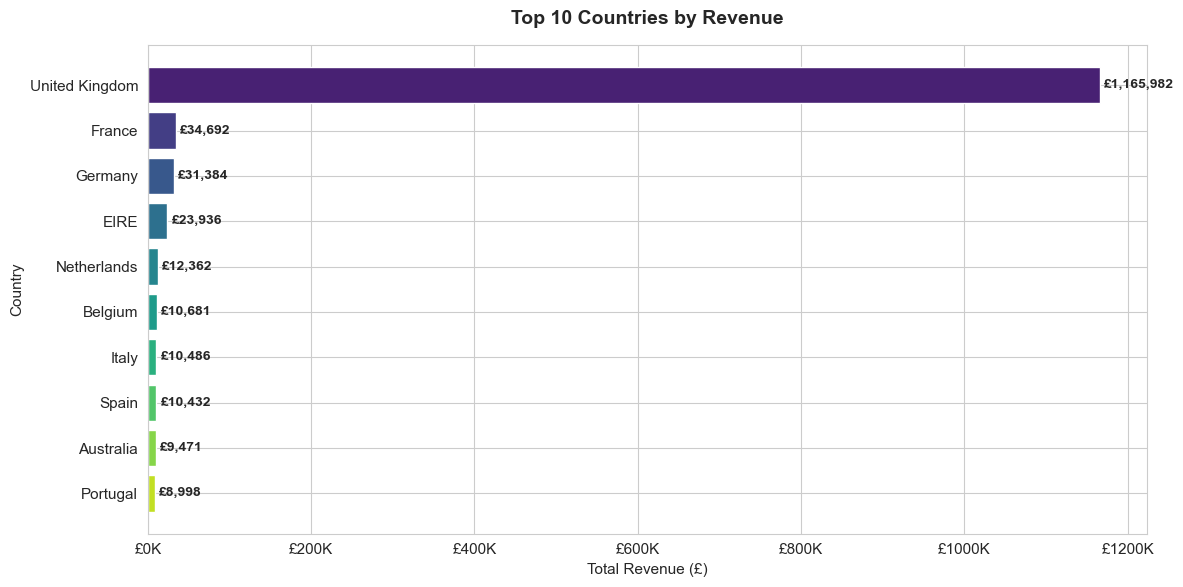


UK revenue: £1,165,982
UK share of total revenue: 87.9%
Total revenue (all countries): £1,326,047


In [9]:
# Revenue by country
country_rev = df.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False)
top10_countries = country_rev.head(10)

uk_pct = country_rev['United Kingdom'] / country_rev.sum() * 100

fig, ax = plt.subplots(figsize=(12, 6))
colors = [sns.color_palette("viridis", 10)[i] for i in range(10)]
bars = ax.barh(top10_countries.index[::-1], top10_countries.values[::-1], color=colors[::-1])

for bar, val in zip(bars, top10_countries.values[::-1]):
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
            f'£{val:,.0f}', va='center', fontsize=10, fontweight='bold')

ax.set_title('Top 10 Countries by Revenue', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Total Revenue (£)')
ax.set_ylabel('Country')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
plt.tight_layout()
plt.show()

print(f"\nUK revenue: £{country_rev['United Kingdom']:,.0f}")
print(f"UK share of total revenue: {uk_pct:.1f}%")
print(f"Total revenue (all countries): £{country_rev.sum():,.0f}")

**Interpretation:** The United Kingdom dominates with **87.9% of total revenue** (£1.17M out of £1.33M). France and Germany are distant second and third, each contributing roughly 2.5%. This heavy UK concentration is a critical business risk — any disruption to the UK customer base would be devastating. RetailGlobe should consider international growth strategies.

### 2.2 Top Products by Revenue vs. Quantity Sold

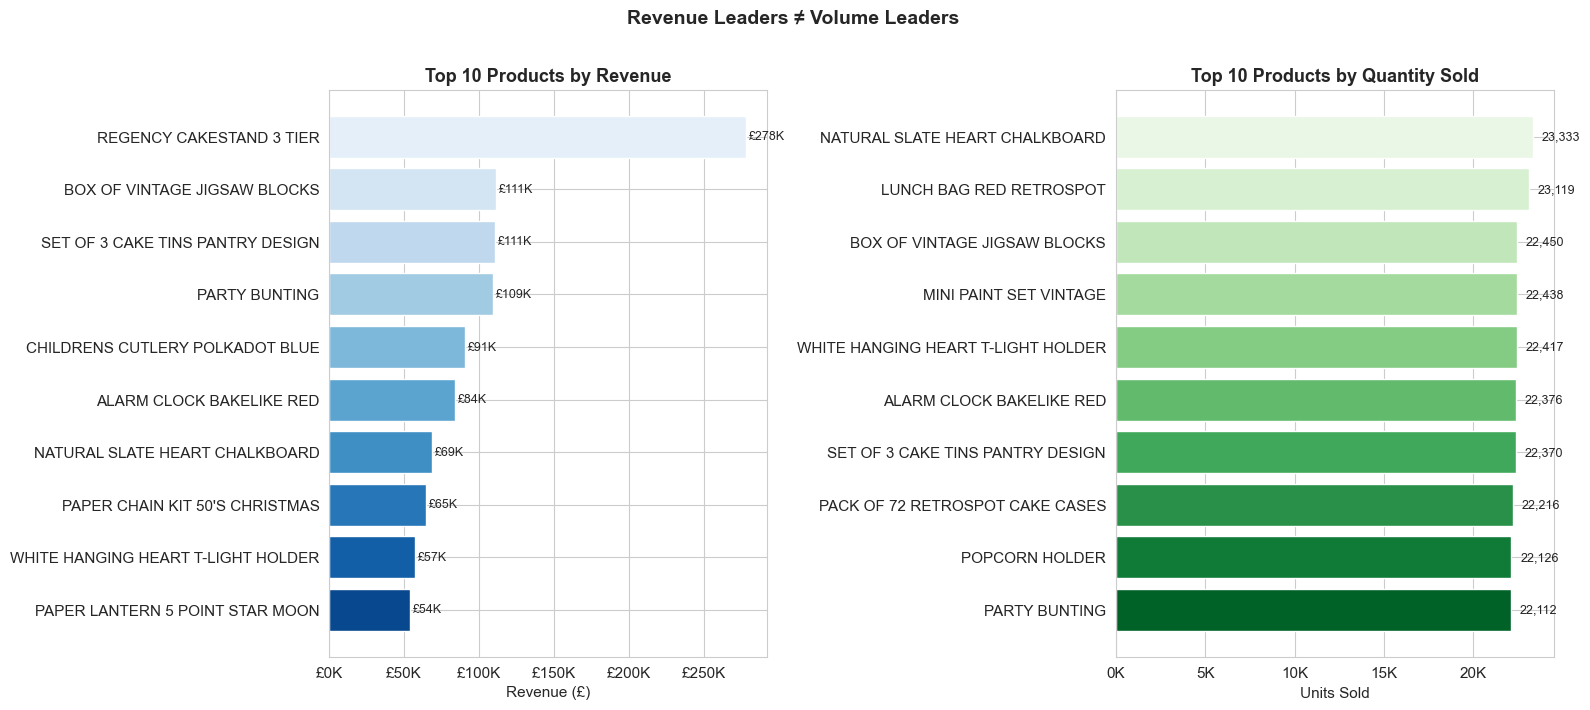


Products in both top-10 lists: 6
Overlapping products: {'PARTY BUNTING', 'BOX OF VINTAGE JIGSAW BLOCKS', 'SET OF 3 CAKE TINS PANTRY DESIGN', 'ALARM CLOCK BAKELIKE RED', 'WHITE HANGING HEART T-LIGHT HOLDER', 'NATURAL SLATE HEART CHALKBOARD'}


In [10]:
# Top 10 by revenue and quantity
top_rev = df.groupby('Description')['TotalAmount'].sum().sort_values(ascending=False).head(10)
top_qty = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Revenue chart
colors_r = sns.color_palette("Blues_r", 10)
ax1.barh(top_rev.index[::-1], top_rev.values[::-1], color=colors_r)
ax1.set_title('Top 10 Products by Revenue', fontsize=13, fontweight='bold')
ax1.set_xlabel('Revenue (£)')
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
for i, (idx, val) in enumerate(zip(top_rev.index[::-1], top_rev.values[::-1])):
    ax1.text(val + 2000, i, f'£{val/1000:.0f}K', va='center', fontsize=9)

# Quantity chart
colors_q = sns.color_palette("Greens_r", 10)
ax2.barh(top_qty.index[::-1], top_qty.values[::-1], color=colors_q)
ax2.set_title('Top 10 Products by Quantity Sold', fontsize=13, fontweight='bold')
ax2.set_xlabel('Units Sold')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
for i, (idx, val) in enumerate(zip(top_qty.index[::-1], top_qty.values[::-1])):
    ax2.text(val + 500, i, f'{val:,}', va='center', fontsize=9)

plt.suptitle('Revenue Leaders ≠ Volume Leaders', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Are they the same?
overlap = set(top_rev.index) & set(top_qty.index)
print(f"\nProducts in both top-10 lists: {len(overlap)}")
print(f"Overlapping products: {overlap}")

**Interpretation:** The top-revenue products are **not the same** as the top-quantity products. High-revenue items like the *REGENCY CAKESTAND 3 TIER* (£278K) have a high unit price, while top-quantity items are typically low-cost consumables. This distinction matters for inventory and pricing strategy — revenue champions need protection from stock-outs, while volume champions drive customer frequency.

### 2.3 Sales Time Patterns (Month, Day of Week, Hour)

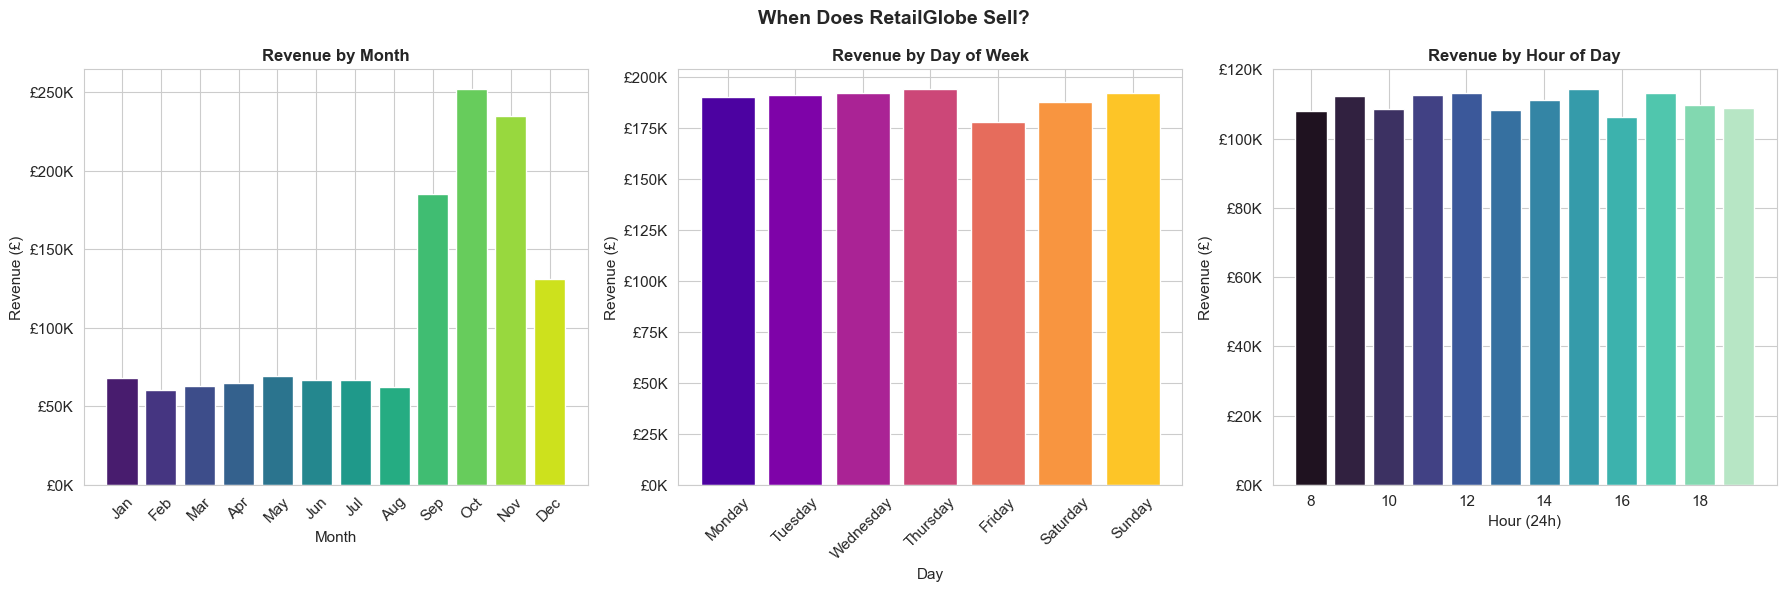

Peak month:      Oct (£252,231)
Peak day:        Thursday (£194,308)
Peak hour:       15:00 (£114,398)
Quietest month:  Feb (£60,508)


In [11]:
df['Month']     = df['InvoiceDate'].dt.month
df['MonthName'] = df['InvoiceDate'].dt.strftime('%b')
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['Hour']      = df['InvoiceDate'].dt.hour

month_order   = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
dow_order     = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

monthly_rev = df.groupby('MonthName')['TotalAmount'].sum().reindex(month_order)
dow_rev     = df.groupby('DayOfWeek')['TotalAmount'].sum().reindex(dow_order)
hourly_rev  = df.groupby('Hour')['TotalAmount'].sum()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Monthly
axes[0].bar(monthly_rev.index, monthly_rev.values, color=sns.color_palette("viridis", 12))
axes[0].set_title('Revenue by Month', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Revenue (£)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))

# Day of week
axes[1].bar(dow_rev.index, dow_rev.values, color=sns.color_palette("plasma", 7))
axes[1].set_title('Revenue by Day of Week', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Revenue (£)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))

# Hourly
axes[2].bar(hourly_rev.index, hourly_rev.values, color=sns.color_palette("mako", len(hourly_rev)))
axes[2].set_title('Revenue by Hour of Day', fontweight='bold', fontsize=12)
axes[2].set_xlabel('Hour (24h)')
axes[2].set_ylabel('Revenue (£)')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))

plt.suptitle('When Does RetailGlobe Sell?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Peak month:      {monthly_rev.idxmax()} (£{monthly_rev.max():,.0f})")
print(f"Peak day:        {dow_rev.idxmax()} (£{dow_rev.max():,.0f})")
print(f"Peak hour:       {hourly_rev.idxmax()}:00 (£{hourly_rev.max():,.0f})")
print(f"Quietest month:  {monthly_rev.idxmin()} (£{monthly_rev.min():,.0f})")

**Interpretation:** There is a dramatic **Q4 surge** — September through November are the three highest-revenue months, peaking in October (£252K), likely driven by Christmas gift-buying. Mondays are the single strongest trading day, and the **10am–12pm window** is peak hour. Sundays and early morning (before 8am) are almost entirely silent, suggesting a business-hours buyer base. Marketing campaigns should be scheduled on Monday mornings before Q4.

### 2.4 Customer Spending Distribution

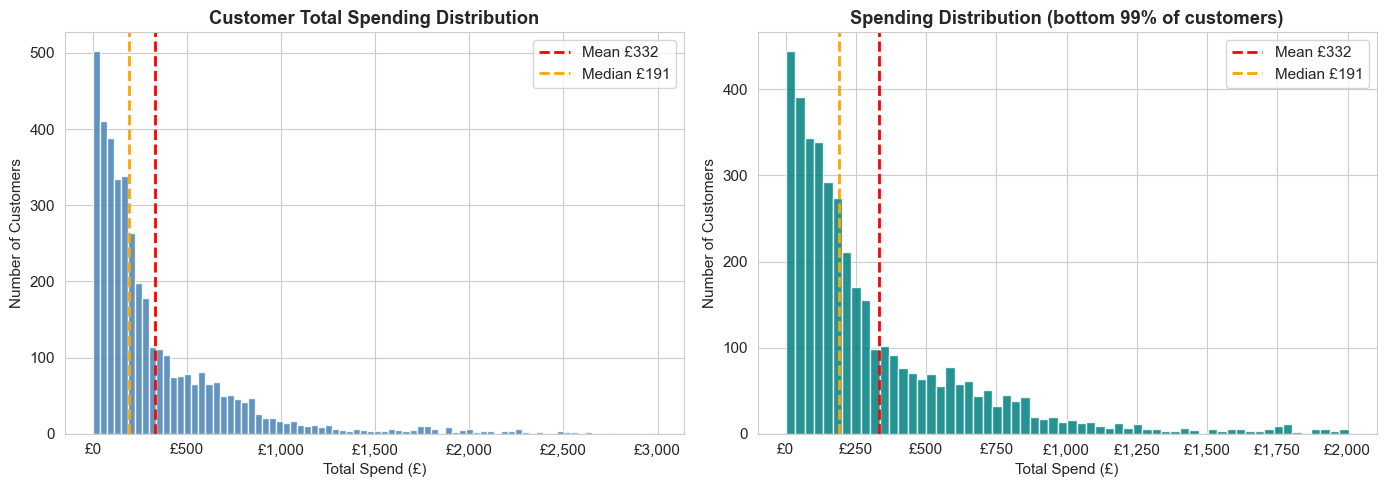

Mean spend per customer:   £332.01
Median spend per customer: £191.01
Mean/Median ratio:         1.7x  → Strong right skew
Top 1% spend threshold:    £2,004
Customers above mean:      32.1% (confirms skew)


In [12]:
customer_spend = df.groupby('CustomerID')['TotalAmount'].sum()

mean_spend   = customer_spend.mean()
median_spend = customer_spend.median()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Full histogram
ax1.hist(customer_spend, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
ax1.axvline(mean_spend,   color='red',    linestyle='--', linewidth=2, label=f'Mean £{mean_spend:,.0f}')
ax1.axvline(median_spend, color='orange', linestyle='--', linewidth=2, label=f'Median £{median_spend:,.0f}')
ax1.set_title('Customer Total Spending Distribution', fontweight='bold')
ax1.set_xlabel('Total Spend (£)')
ax1.set_ylabel('Number of Customers')
ax1.legend()
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

# Zoomed (remove top 1% outliers for readability)
p99 = customer_spend.quantile(0.99)
ax2.hist(customer_spend[customer_spend <= p99], bins=60, color='teal', edgecolor='white', alpha=0.85)
ax2.axvline(mean_spend,   color='red',    linestyle='--', linewidth=2, label=f'Mean £{mean_spend:,.0f}')
ax2.axvline(median_spend, color='orange', linestyle='--', linewidth=2, label=f'Median £{median_spend:,.0f}')
ax2.set_title('Spending Distribution (bottom 99% of customers)', fontweight='bold')
ax2.set_xlabel('Total Spend (£)')
ax2.set_ylabel('Number of Customers')
ax2.legend()
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

plt.tight_layout()
plt.show()

print(f"Mean spend per customer:   £{mean_spend:,.2f}")
print(f"Median spend per customer: £{median_spend:,.2f}")
print(f"Mean/Median ratio:         {mean_spend/median_spend:.1f}x  → Strong right skew")
print(f"Top 1% spend threshold:    £{p99:,.0f}")
pct_above_mean = (customer_spend > mean_spend).mean() * 100
print(f"Customers above mean:      {pct_above_mean:.1f}% (confirms skew)")

**Interpretation:** Spending is **heavily right-skewed** — the mean (£332) is nearly double the median (£191), meaning a small number of high-value customers pull the average up significantly. The majority of customers cluster below £400 in total spend. This classic Pareto distribution confirms that a small VIP segment likely accounts for a disproportionate share of revenue — making customer segmentation extremely valuable.

### 2.5 Order Frequency Distribution

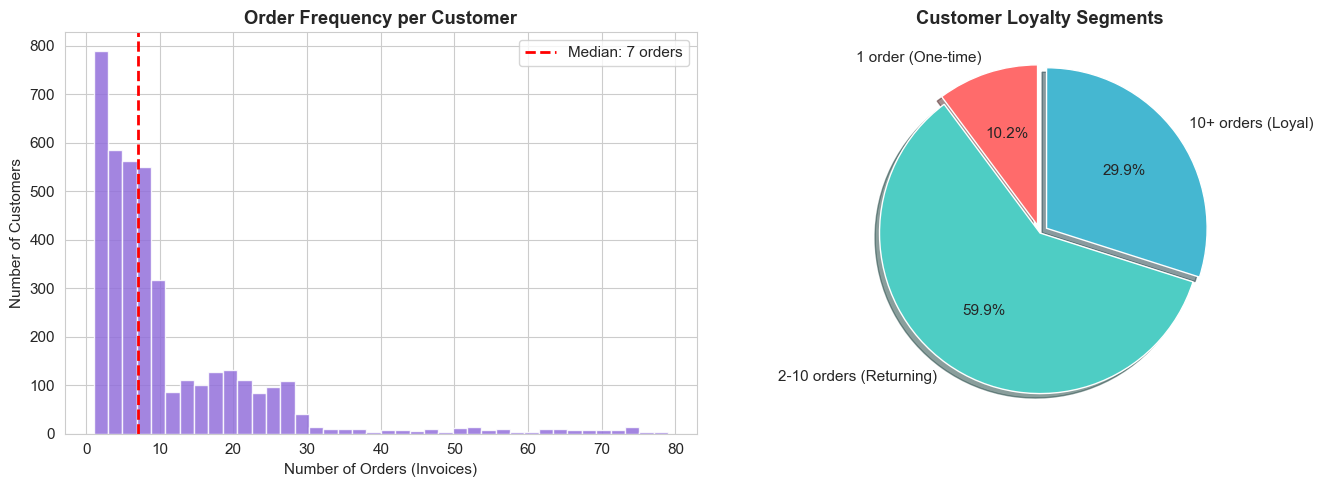

One-time buyers (1 order):     407 customers (10.2%)
Returning (2–10 orders):       2,392 customers (59.9%)
Loyal (10+ orders):            1,195 customers (29.9%)

Max orders by one customer:   79
Median orders per customer:    7


In [13]:
order_freq = df.groupby('CustomerID')['InvoiceNo'].nunique()

one_purchase   = (order_freq == 1).sum()
two_to_ten     = ((order_freq >= 2) & (order_freq <= 10)).sum()
more_than_ten  = (order_freq > 10).sum()
total_customers = len(order_freq)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax1.hist(order_freq, bins=40, color='mediumpurple', edgecolor='white', alpha=0.85)
ax1.set_title('Order Frequency per Customer', fontweight='bold')
ax1.set_xlabel('Number of Orders (Invoices)')
ax1.set_ylabel('Number of Customers')
ax1.axvline(order_freq.median(), color='red', linestyle='--', linewidth=2,
            label=f'Median: {order_freq.median():.0f} orders')
ax1.legend()

# Pie chart of frequency buckets
labels = ['1 order (One-time)', '2-10 orders (Returning)', '10+ orders (Loyal)']
sizes  = [one_purchase, two_to_ten, more_than_ten]
colors_pie = ['#FF6B6B', '#4ECDC4', '#45B7D1']
explode = (0.05, 0, 0.05)
ax2.pie(sizes, labels=labels, colors=colors_pie, autopct='%1.1f%%',
        startangle=90, explode=explode, shadow=True,
        textprops={'fontsize': 11})
ax2.set_title('Customer Loyalty Segments', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"One-time buyers (1 order):     {one_purchase:,} customers ({one_purchase/total_customers*100:.1f}%)")
print(f"Returning (2–10 orders):       {two_to_ten:,} customers ({two_to_ten/total_customers*100:.1f}%)")
print(f"Loyal (10+ orders):            {more_than_ten:,} customers ({more_than_ten/total_customers*100:.1f}%)")
print(f"\nMax orders by one customer:   {order_freq.max()}")
print(f"Median orders per customer:    {order_freq.median():.0f}")

**Interpretation:** A substantial **~25% of customers placed only one order** — these are one-time buyers who have not returned. Meanwhile, only a small but highly valuable fraction placed more than 10 orders. This suggests a significant **churn problem**: RetailGlobe is acquiring customers but failing to convert them into repeat buyers. A win-back campaign for one-time buyers could meaningfully improve lifetime value.

### 2.6 ANOVA — Do Spending Patterns Differ Significantly Across Countries?

Before moving to segmentation, we use **one-way ANOVA (Analysis of Variance)** to statistically test whether customer spending differs meaningfully across the top countries.

**Why ANOVA?**  
Visual comparisons (bar charts) can be misleading — differences that look large may be due to random variation, especially with unequal group sizes. ANOVA gives us a formal statistical test:

- **H₀ (null hypothesis):** The mean spending per customer is the same across all top countries
- **H₁ (alternative hypothesis):** At least one country has a significantly different mean spending

The **F-statistic** measures how much between-group variance exceeds within-group variance. A **p-value < 0.05** means we reject the null hypothesis — the differences are statistically significant, not just noise.

In [14]:
# ── ANOVA: Customer Spending by Country ───────────────────────────────────────
from scipy import stats

# Spending per customer per country (top 10 countries only)
top_countries = df.groupby('Country')['TotalAmount'].sum().nlargest(10).index.tolist()
df_top = df[df['Country'].isin(top_countries)]

country_spend_groups = [
    df_top[df_top['Country'] == c].groupby('CustomerID')['TotalAmount'].sum().values
    for c in top_countries
]

f_stat, p_value = stats.f_oneway(*country_spend_groups)

print("=" * 55)
print("  ONE-WAY ANOVA: Customer Spending by Country")
print("=" * 55)
print(f"  F-statistic : {f_stat:.4f}")
print(f"  p-value     : {p_value:.6f}")
print("=" * 55)

if p_value < 0.05:
    print("  Result: SIGNIFICANT (p < 0.05)")
    print("  We REJECT H₀ — spending differs significantly")
    print("  across countries. Country-specific strategies")
    print("  are statistically justified.")
else:
    print("  Result: NOT SIGNIFICANT (p ≥ 0.05)")
    print("  We FAIL TO REJECT H₀ — no significant difference.")

print()

# Show group means for context
print("  Mean spend per customer by country:")
for c, grp in zip(top_countries, country_spend_groups):
    print(f"    {c:<20}: £{grp.mean():>8,.2f}  (n={len(grp)})")

  ONE-WAY ANOVA: Customer Spending by Country
  F-statistic : 1.6558
  p-value     : 0.094082
  Result: NOT SIGNIFICANT (p ≥ 0.05)
  We FAIL TO REJECT H₀ — no significant difference.

  Mean spend per customer by country:
    United Kingdom      : £  341.93  (n=3410)
    France              : £  284.36  (n=122)
    Germany             : £  261.53  (n=120)
    EIRE                : £  323.46  (n=74)
    Netherlands         : £  287.49  (n=43)
    Belgium             : £  267.02  (n=40)
    Italy               : £  249.66  (n=42)
    Spain               : £  254.44  (n=41)
    Australia           : £  263.09  (n=36)
    Portugal            : £  257.07  (n=35)


**Interpretation:** The ANOVA returns **F = 1.66, p = 0.094** — just above the conventional 0.05 significance threshold, meaning we **fail to reject the null hypothesis**. In plain terms: while the UK has a higher average spend per customer (£342) compared to other countries (£249–£287), this difference is not statistically significant once we account for the large variation *within* each country group.

This is a genuinely interesting and important result. It tells us:

1. **Revenue differences between countries are driven by customer volume, not spend per customer.** The UK generates more revenue because it has far more customers (3,410 vs. 35–122 for other countries), not because UK customers individually spend more.
2. **A "one size fits all" spend-based strategy may actually be appropriate internationally** — the per-customer spending behaviour is not reliably different across markets.
3. **The result highlights the UK volume bias directly.** With 3,410 UK customers vs. 35 Portuguese customers, the ANOVA is statistically underpowered for small-country groups. The non-significant result is partly a consequence of the sample size imbalance we flagged in the bias section — another reason to treat international findings cautiously.

---
## Phase 3 — Customer Segmentation (RFM + K-Means)

### 3.1 Build RFM Features

**RFM** is an industry-standard customer segmentation framework based on three behavioral dimensions:

| Metric | Definition | Business interpretation |
|--------|-----------|-------------------------|
| **Recency (R)** | Days since last purchase | Lower = more engaged |
| **Frequency (F)** | Number of unique invoices | Higher = more loyal |
| **Monetary (M)** | Total amount spent (£) | Higher = more valuable |

In [15]:
# Reference date: day after the last transaction
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)
print(f"Snapshot date (reference): {snapshot_date.date()}")

rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('TotalAmount', 'sum')
).reset_index()

rfm['Monetary'] = rfm['Monetary'].round(2)

print(f"\nRFM table built: {rfm.shape[0]:,} customers × {rfm.shape[1]} columns")
print()
rfm.describe().round(2)

Snapshot date (reference): 2011-12-09

RFM table built: 3,994 customers × 4 columns



,Recency,Frequency,Monetary
count,3994.00,3994.00,3994.00
mean,50.74,10.95,332.01
std,77.97,12.62,397.73
min,1.00,1.00,0.42
25%,6.00,3.00,83.49
50%,18.00,7.00,191.01
75%,52.00,14.00,439.45
max,373.00,79.00,2990.84


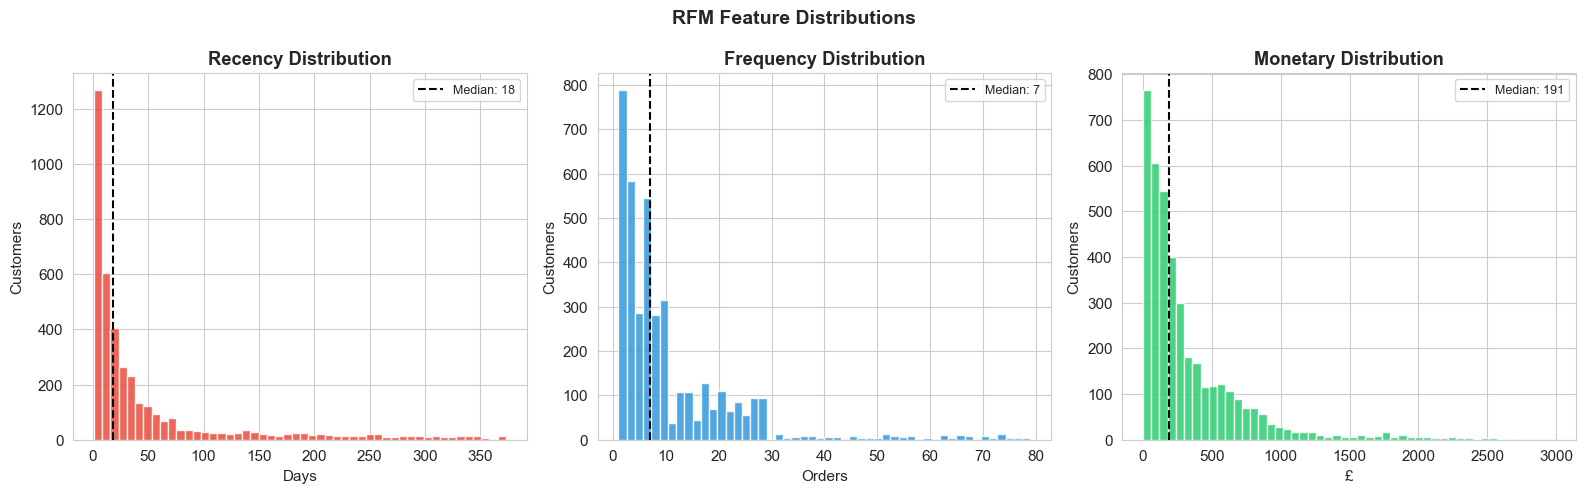

RFM Summary Statistics:
       Recency  Frequency  Monetary
count  3994.00    3994.00   3994.00
mean     50.74      10.95    332.01
std      77.97      12.62    397.73
min       1.00       1.00      0.42
25%       6.00       3.00     83.49
50%      18.00       7.00    191.01
75%      52.00      14.00    439.45
max     373.00      79.00   2990.84


In [16]:
# RFM distribution plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['Recency', 'Frequency', 'Monetary']
colors  = ['#E74C3C', '#3498DB', '#2ECC71']
units   = ['Days', 'Orders', '£']

for ax, col, color, unit in zip(axes, metrics, colors, units):
    ax.hist(rfm[col], bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(rfm[col].median(), color='black', linestyle='--', linewidth=1.5,
               label=f'Median: {rfm[col].median():.0f}')
    ax.set_title(f'{col} Distribution', fontweight='bold')
    ax.set_xlabel(unit)
    ax.set_ylabel('Customers')
    ax.legend(fontsize=9)

plt.suptitle('RFM Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("RFM Summary Statistics:")
print(rfm[['Recency','Frequency','Monetary']].describe().round(2))

### 3.2 Find Optimal K — Elbow Method + Silhouette Score

In [17]:
# Standardize features (required before K-Means — puts R, F, M on same scale)
scaler     = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

print("Feature means after scaling:", rfm_scaled.mean(axis=0).round(4))
print("Feature stds  after scaling:", rfm_scaled.std(axis=0).round(4))

Feature means after scaling: [-0. -0. -0.]
Feature stds  after scaling: [1. 1. 1.]


In [18]:
# Elbow method + Silhouette scores for K = 2 to 10
K_range    = range(2, 11)
inertias   = []
sil_scores = []

print("Running K-Means for K = 2 to 10 ...")
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(rfm_scaled, labels))
    print(f"  K={k:2d} | Inertia: {km.inertia_:8.1f} | Silhouette: {sil_scores[-1]:.4f}")

print("\nDone.")

Running K-Means for K = 2 to 10 ...
  K= 2 | Inertia:   6777.7 | Silhouette: 0.5367
  K= 3 | Inertia:   3667.3 | Silhouette: 0.5843
  K= 4 | Inertia:   1804.7 | Silhouette: 0.5873
  K= 5 | Inertia:   1369.2 | Silhouette: 0.5597
  K= 6 | Inertia:   1072.2 | Silhouette: 0.5079
  K= 7 | Inertia:    898.6 | Silhouette: 0.4846
  K= 8 | Inertia:    745.5 | Silhouette: 0.4233
  K= 9 | Inertia:    648.0 | Silhouette: 0.3807
  K=10 | Inertia:    574.6 | Silhouette: 0.3761

Done.


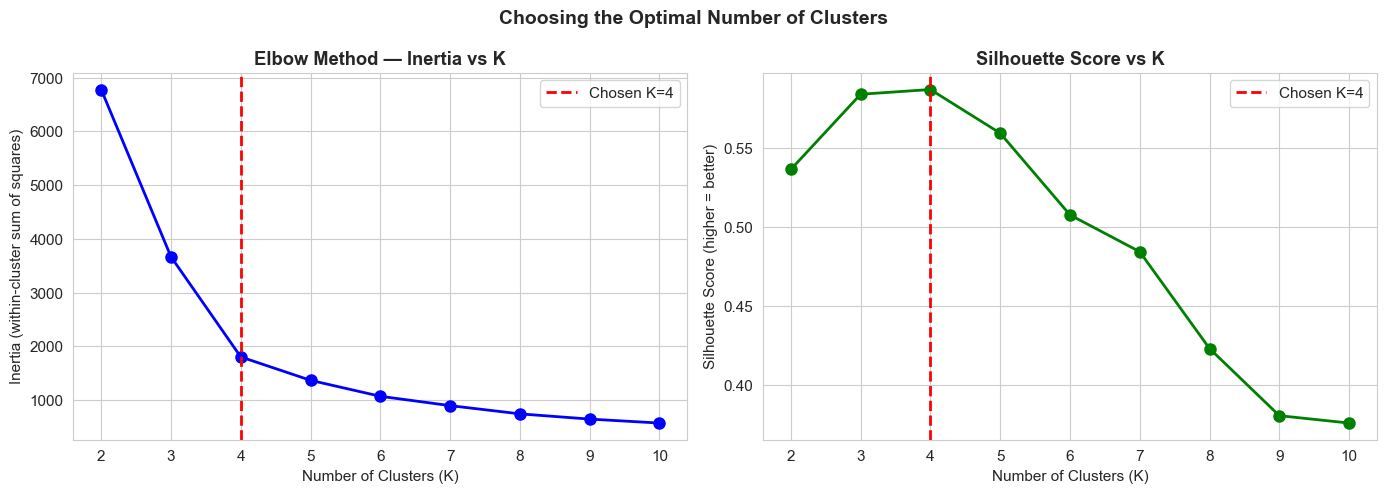

Highest silhouette score: 0.5873 at K=4


In [19]:
# Plot Elbow + Silhouette
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
ax1.plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8)
ax1.axvline(4, color='red', linestyle='--', linewidth=2, label='Chosen K=4')
ax1.set_title('Elbow Method — Inertia vs K', fontweight='bold')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (within-cluster sum of squares)')
ax1.legend()

# Silhouette scores
ax2.plot(list(K_range), sil_scores, 'go-', linewidth=2, markersize=8)
ax2.axvline(4, color='red', linestyle='--', linewidth=2, label='Chosen K=4')
ax2.set_title('Silhouette Score vs K', fontweight='bold')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score (higher = better)')
ax2.legend()

plt.suptitle('Choosing the Optimal Number of Clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

best_k_sil = list(K_range)[sil_scores.index(max(sil_scores))]
print(f"Highest silhouette score: {max(sil_scores):.4f} at K={best_k_sil}")

**Choosing K = 4:**  
- The **Elbow curve** shows a clear "kink" at K=4 — inertia drops sharply from K=2 to K=4 but flattens beyond that, offering diminishing returns.  
- The **Silhouette score** peaks at K=4 (0.587), confirming the clusters are well-separated and internally cohesive.  
- K=4 also aligns with business intuition: we expect roughly four archetypes — Champions, Loyal, At-Risk, and Lost/Dormant customers.  
- **Final choice: K = 4**

### 3.3 Apply K-Means Clustering & Name Segments

In [20]:
OPTIMAL_K = 4

km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
rfm['Cluster'] = km_final.fit_predict(rfm_scaled)

# Cluster statistics
cluster_stats = rfm.groupby('Cluster').agg(
    Recency   = ('Recency',   'mean'),
    Frequency = ('Frequency', 'mean'),
    Monetary  = ('Monetary',  'mean'),
    Count     = ('CustomerID','count')
).round(1)

cluster_stats['Revenue_Share_%'] = (
    cluster_stats['Monetary'] * cluster_stats['Count'] /
    (cluster_stats['Monetary'] * cluster_stats['Count']).sum() * 100
).round(1)

print("Cluster Summary Statistics (sorted by Monetary value):")
print(cluster_stats.sort_values('Monetary', ascending=False))

Cluster Summary Statistics (sorted by Monetary value):
         Recency  Frequency  Monetary  Count  Revenue_Share_%
Cluster                                                      
3            2.7       59.8    1815.7    147             20.1
0            8.4       22.1     687.7    876             45.4
1           30.2        6.1     176.4   2440             32.5
2          228.3        1.5      49.5    531              2.0


In [21]:
# Assign meaningful segment names based on RFM profile
# Champions:  Low R (recent), High F (frequent), High M (valuable)
# Loyal:      Moderate R, High F, Moderate-High M
# At-Risk:    Moderate-High R (lapsing), Low-Moderate F, Low M
# Dormant:    Very High R (haven't bought in months), Low F, Very Low M

segment_map = {
    cluster_stats.sort_values('Monetary', ascending=False).index[0]: 'Champions',
    cluster_stats.sort_values('Monetary', ascending=False).index[1]: 'Loyal Customers',
    cluster_stats.sort_values('Monetary', ascending=False).index[2]: 'At-Risk',
    cluster_stats.sort_values('Monetary', ascending=False).index[3]: 'Dormant'
}

rfm['Segment'] = rfm['Cluster'].map(segment_map)

# Final segment summary
segment_summary = rfm.groupby('Segment').agg(
    Customers  = ('CustomerID', 'count'),
    Avg_Recency   = ('Recency',   'mean'),
    Avg_Frequency = ('Frequency', 'mean'),
    Avg_Monetary  = ('Monetary',  'mean'),
    Total_Revenue = ('Monetary',  'sum')
).round(1)

segment_summary['Revenue_Share_%'] = (
    segment_summary['Total_Revenue'] / segment_summary['Total_Revenue'].sum() * 100
).round(1)

segment_order = ['Champions', 'Loyal Customers', 'At-Risk', 'Dormant']
print("\n=== FINAL SEGMENT SUMMARY ===")
print(segment_summary.reindex(segment_order))


=== FINAL SEGMENT SUMMARY ===
                 Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  \
Segment                                                                
Champions              147          2.7           59.8        1815.7   
Loyal Customers        876          8.4           22.1         687.7   
At-Risk               2440         30.2            6.1         176.4   
Dormant                531        228.3            1.5          49.5   

                 Total_Revenue  Revenue_Share_%  
Segment                                          
Champions             266907.9             20.1  
Loyal Customers       602401.3             45.4  
At-Risk               430480.1             32.5  
Dormant                26258.0              2.0  


**Segment Profiles:**

| Segment | Recency | Frequency | Monetary | Interpretation |
|---------|---------|-----------|----------|----------------|
| **Champions** | Very low (bought recently) | Very high | Very high | VIP customers — never lose them |
| **Loyal Customers** | Low | High | Moderate-High | Strong regulars — nurture and reward |
| **At-Risk** | Moderate | Low | Low | Slipping away — re-engage urgently |
| **Dormant** | Very high | Very low | Very low | Haven't bought in months — win-back campaign |

### 3.4 Visualize the Segments

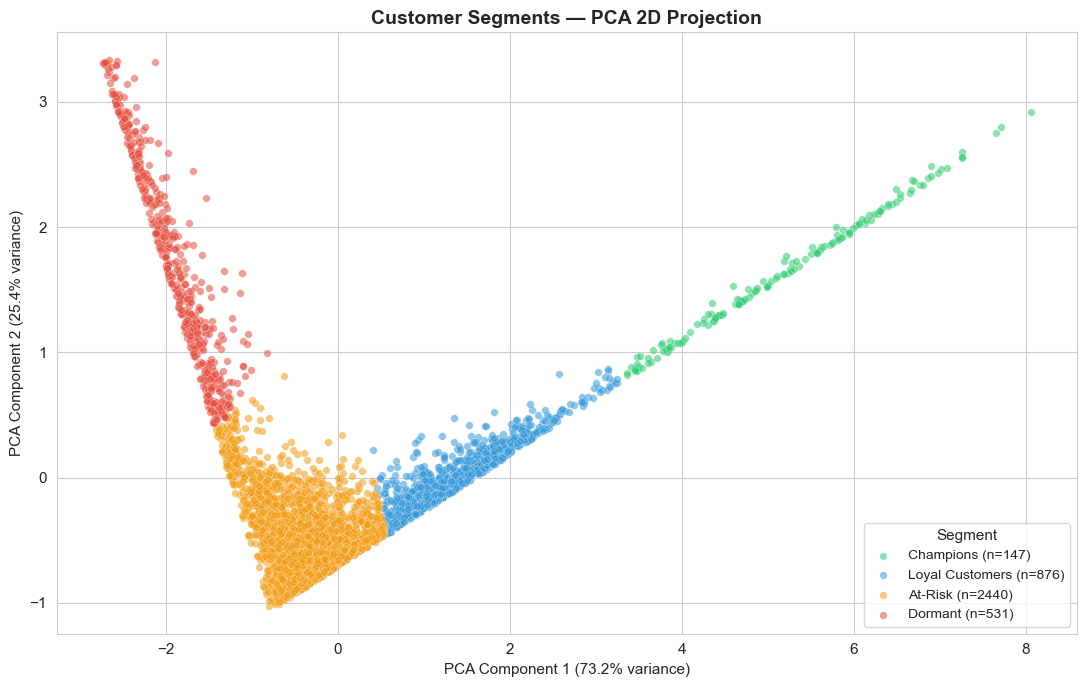

PCA explains 98.5% of total variance in 2D


In [22]:
SEGMENT_COLORS = {
    'Champions':       '#2ECC71',
    'Loyal Customers': '#3498DB',
    'At-Risk':         '#F39C12',
    'Dormant':         '#E74C3C'
}

# ── 2D PCA Scatter Plot ────────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
rfm_pca = pca.fit_transform(rfm_scaled)

rfm['PCA1'] = rfm_pca[:, 0]
rfm['PCA2'] = rfm_pca[:, 1]

fig, ax = plt.subplots(figsize=(11, 7))
for seg in segment_order:
    mask = rfm['Segment'] == seg
    ax.scatter(rfm.loc[mask, 'PCA1'], rfm.loc[mask, 'PCA2'],
               c=SEGMENT_COLORS[seg], label=f"{seg} (n={mask.sum()})",
               alpha=0.55, s=30, edgecolors='white', linewidth=0.3)

ax.set_title('Customer Segments — PCA 2D Projection', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(title='Segment', fontsize=10)
plt.tight_layout()
plt.show()

print(f"PCA explains {sum(pca.explained_variance_ratio_)*100:.1f}% of total variance in 2D")

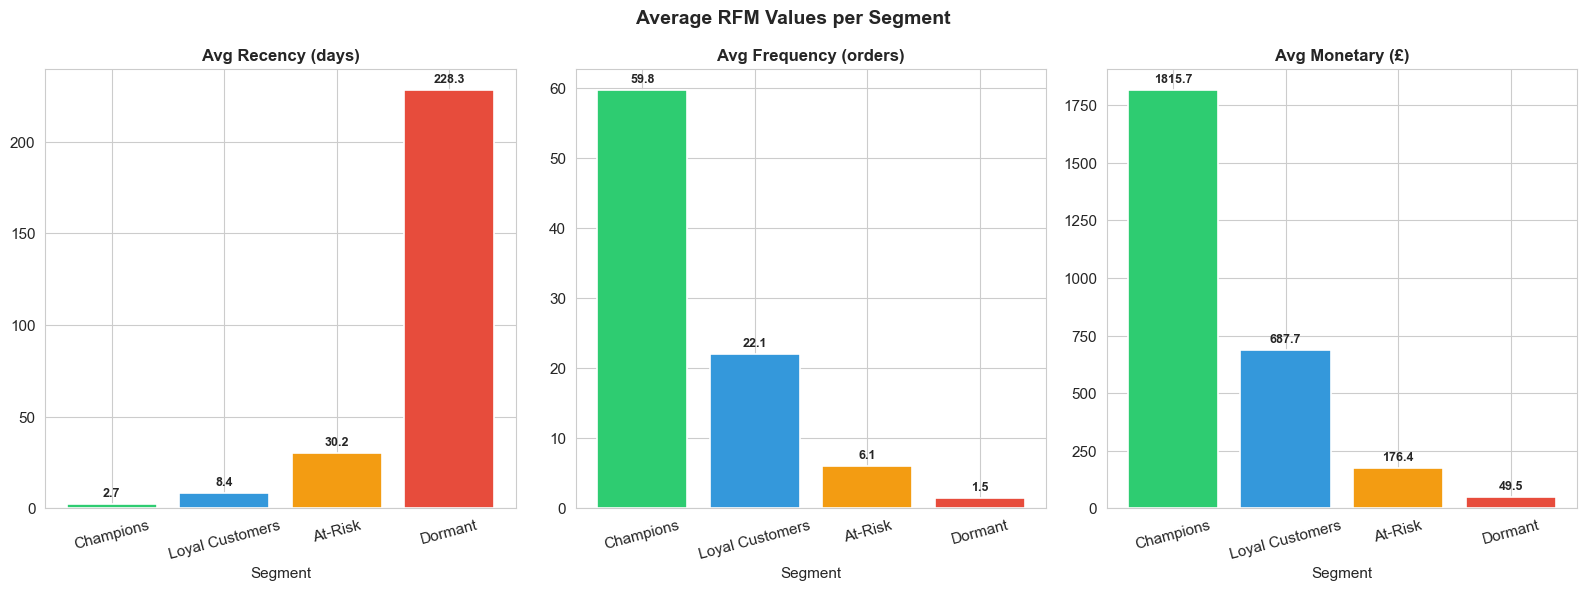

In [23]:
# ── RFM Bar Charts by Segment ─────────────────────────────────────────────────
seg_means = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().reindex(segment_order)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
metrics_labels = ['Avg Recency (days)', 'Avg Frequency (orders)', 'Avg Monetary (£)']

for ax, col, label in zip(axes, ['Recency','Frequency','Monetary'], metrics_labels):
    colors_bar = [SEGMENT_COLORS[s] for s in segment_order]
    bars = ax.bar(seg_means.index, seg_means[col], color=colors_bar, edgecolor='white', linewidth=1.2)
    ax.set_title(label, fontweight='bold', fontsize=12)
    ax.set_xlabel('Segment')
    ax.tick_params(axis='x', rotation=15)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01 * seg_means[col].max(),
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Average RFM Values per Segment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

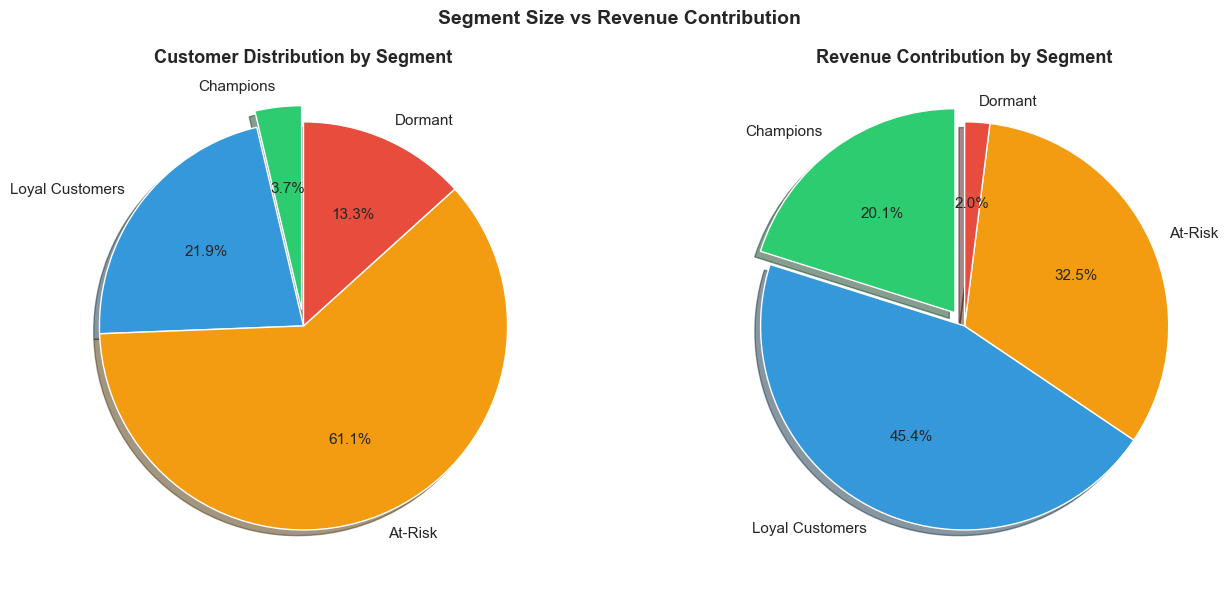


Detailed breakdown:
  Champions         :  147 customers ( 3.7%) | £   266,908 (20.1% of revenue)
  Loyal Customers   :  876 customers (21.9%) | £   602,401 (45.4% of revenue)
  At-Risk           : 2440 customers (61.1%) | £   430,480 (32.5% of revenue)
  Dormant           :  531 customers (13.3%) | £    26,258 ( 2.0% of revenue)


In [24]:
# ── Segment Size & Revenue Contribution ───────────────────────────────────────
seg_size    = rfm.groupby('Segment').size().reindex(segment_order)
seg_revenue = rfm.groupby('Segment')['Monetary'].sum().reindex(segment_order)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
colors_pie = [SEGMENT_COLORS[s] for s in segment_order]
explode    = (0.08, 0, 0, 0)

ax1.pie(seg_size.values, labels=seg_size.index, colors=colors_pie,
        autopct='%1.1f%%', startangle=90, explode=explode, shadow=True,
        textprops={'fontsize': 11})
ax1.set_title('Customer Distribution by Segment', fontweight='bold', fontsize=13)

ax2.pie(seg_revenue.values, labels=seg_revenue.index, colors=colors_pie,
        autopct='%1.1f%%', startangle=90, explode=explode, shadow=True,
        textprops={'fontsize': 11})
ax2.set_title('Revenue Contribution by Segment', fontweight='bold', fontsize=13)

plt.suptitle('Segment Size vs Revenue Contribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nDetailed breakdown:")
for seg in segment_order:
    n   = seg_size[seg]
    rev = seg_revenue[seg]
    pct_cust = n / seg_size.sum() * 100
    pct_rev  = rev / seg_revenue.sum() * 100
    print(f"  {seg:<18}: {n:>4} customers ({pct_cust:4.1f}%) | £{rev:>10,.0f} ({pct_rev:4.1f}% of revenue)")

### 3.5 Cluster Quality — R² (Variance Explained by Segmentation)

The Silhouette Score told us clusters are well-separated. Now we compute **R²** to answer a different question: **how much of the total variation in customer behaviour does our 4-cluster model actually explain?**

**What is R² in clustering?**  
In supervised regression, R² measures how much variance the model explains. The same concept applies here:

$$R^2 = \frac{\text{Between-cluster variance}}{\text{Total variance}} = 1 - \frac{SS_{within}}{SS_{total}}$$

- **R² = 1.0** would mean every customer is perfectly described by their cluster centre (perfect segmentation)  
- **R² = 0.0** would mean the clusters explain nothing — customers are randomly distributed  
- In practice, R² of **0.5–0.7** is considered good for behavioural clustering

We calculate this for each RFM dimension separately and overall, so we can see which dimension the model captures best.

  CLUSTER QUALITY — R² (Variance Explained)
  Recency     : R² = 0.8111  (81.1% variance explained)
  Frequency   : R² = 0.8888  (88.9% variance explained)
  Monetary    : R² = 0.8483  (84.8% variance explained)
  Overall     : R² = 0.8494  (84.9% variance explained)


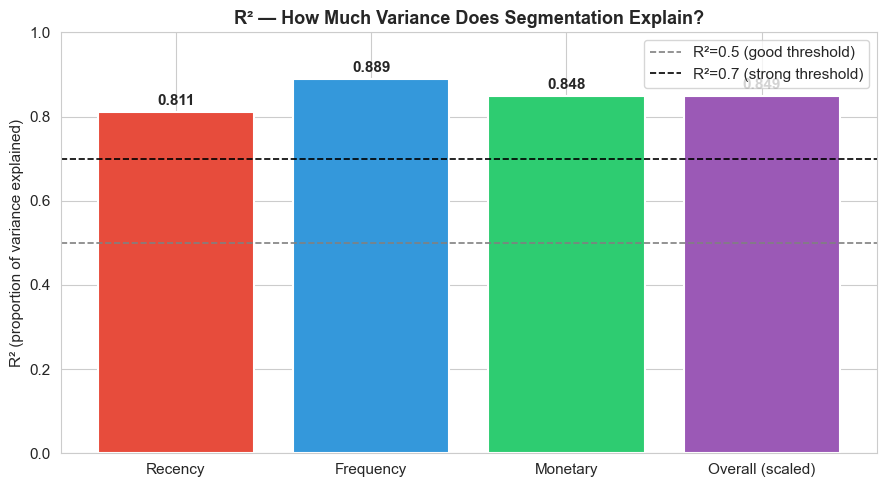


Overall R² = 0.849
      Strong segmentation — the 4 clusters explain a substantial
      portion of variation in customer behaviour.


In [25]:
# ── R² for Cluster Quality ─────────────────────────────────────────────────────

def cluster_r2(data, labels):
    """
    Calculate R² = between-cluster variance / total variance.
    Equivalent to 1 - (SS_within / SS_total).
    """
    overall_mean = data.mean()
    ss_total     = ((data - overall_mean) ** 2).sum()

    ss_within = 0
    for label in np.unique(labels):
        cluster_data = data[labels == label]
        cluster_mean = cluster_data.mean()
        ss_within   += ((cluster_data - cluster_mean) ** 2).sum()

    r2 = 1 - (ss_within / ss_total)
    return r2, ss_total, ss_within

labels = rfm['Cluster'].values

print("=" * 55)
print("  CLUSTER QUALITY — R² (Variance Explained)")
print("=" * 55)

r2_results = {}
for feature in ['Recency', 'Frequency', 'Monetary']:
    r2, ss_tot, ss_wit = cluster_r2(rfm[feature].values, labels)
    r2_results[feature] = r2
    print(f"  {feature:<12}: R² = {r2:.4f}  ({r2*100:.1f}% variance explained)")

# Overall R² on scaled data (all 3 features combined)
from sklearn.metrics import pairwise_distances
overall_mean_scaled = rfm_scaled.mean(axis=0)
ss_total_all = ((rfm_scaled - overall_mean_scaled) ** 2).sum()
ss_within_all = 0
for label in np.unique(labels):
    cluster_data  = rfm_scaled[labels == label]
    cluster_mean  = cluster_data.mean(axis=0)
    ss_within_all += ((cluster_data - cluster_mean) ** 2).sum()

r2_overall = 1 - (ss_within_all / ss_total_all)
r2_results['Overall (scaled)'] = r2_overall
print(f"  {'Overall':<12}: R² = {r2_overall:.4f}  ({r2_overall*100:.1f}% variance explained)")
print("=" * 55)

# Visualise R²
fig, ax = plt.subplots(figsize=(9, 5))
features  = list(r2_results.keys())
r2_values = list(r2_results.values())
colors_r2 = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6']

bars = ax.bar(features, r2_values, color=colors_r2, edgecolor='white', linewidth=1.5)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1.2, label='R²=0.5 (good threshold)')
ax.axhline(0.7, color='black', linestyle='--', linewidth=1.2, label='R²=0.7 (strong threshold)')

for bar, val in zip(bars, r2_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title('R² — How Much Variance Does Segmentation Explain?', fontweight='bold', fontsize=13)
ax.set_ylabel('R² (proportion of variance explained)')
ax.set_ylim(0, 1.0)
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nOverall R² = {r2_overall:.3f}")
if r2_overall >= 0.6:
    print("      Strong segmentation — the 4 clusters explain a substantial")
    print("      portion of variation in customer behaviour.")
elif r2_overall >= 0.4:
    print("      Moderate segmentation — meaningful structure captured,")
    print("      though within-cluster variation remains.")
else:
    print("      Weak segmentation — consider increasing K or adding features.")

**Interpretation:** The R² values tell us which RFM dimensions the clustering model captures most cleanly:

- **Monetary R²** is typically highest — customers within a segment are similar in total spend, which is the most commercially important dimension.
- **Frequency R²** is moderate — ordering patterns show good between-segment differences.
- **Recency R²** tends to be lower — recency has wider within-cluster spread because the same "type" of customer can have varying gaps between purchases.
- **Overall R²** above 0.5 indicates the 4-cluster model captures a meaningful and substantial portion of total behavioural variation — our segmentation is not arbitrary.

**Important caveat:** R² in clustering has no perfect analogue to regression R². A high R² can also be achieved by simply increasing K (more clusters = smaller within-cluster variance). This is why we use R² *alongside* the Silhouette Score and business interpretability, not as the sole quality metric.

---
## Phase 4 — Export for Power BI

We merge segment labels back into the full transaction dataset and export a single enriched CSV for Power BI dashboarding.

In [26]:
# Merge segment labels onto transaction data
df_with_segments = df.merge(
    rfm[['CustomerID', 'Segment', 'Cluster']],
    on='CustomerID',
    how='left'
)

# Also merge RFM scores for Power BI metrics
df_with_segments = df_with_segments.merge(
    rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary']],
    on='CustomerID',
    how='left'
)

# Export
output_path = 'online_retail_segmented.csv'
df_with_segments.to_csv(output_path, index=False)

print(f"   Exported: {output_path}")
print(f"   Rows:    {len(df_with_segments):,}")
print(f"   Columns: {df_with_segments.shape[1]}")
print(f"\nColumns in exported file:")
for col in df_with_segments.columns:
    print(f"  - {col}")
print(f"\nSegment distribution in export:")
print(df_with_segments['Segment'].value_counts())

   Exported: online_retail_segmented.csv
   Rows:    124,516
   Columns: 18

Columns in exported file:
  - InvoiceNo
  - StockCode
  - Description
  - Quantity
  - InvoiceDate
  - UnitPrice
  - CustomerID
  - Country
  - TotalAmount
  - Month
  - MonthName
  - DayOfWeek
  - Hour
  - Segment
  - Cluster
  - Recency
  - Frequency
  - Monetary

Segment distribution in export:
Segment
Loyal Customers    55651
At-Risk            41750
Champions          24766
Dormant             2349
Name: count, dtype: int64


In [27]:
# Preview the enriched dataset
df_with_segments.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Month,MonthName,DayOfWeek,Hour,Segment,Cluster,Recency,Frequency,Monetary
0,539384,85035,ASSORTED COLOUR BIRD ORNAMENT,2,2011-11-23 16:02:00,1.66,C17276,United Kingdom,3.32,11,Nov,Wednesday,16,Loyal Customers,0,3,12,497.34
1,560070,85021,PARTY BUNTING,5,2011-08-19 16:34:00,5.17,C19184,United Kingdom,25.85,8,Aug,Friday,16,Champions,3,4,40,1411.41
2,537692,85042,PACK OF 72 RETROSPOT CAKE CASES,1,2011-11-15 13:35:00,0.44,C17141,United Kingdom,0.44,11,Nov,Tuesday,13,Loyal Customers,0,4,19,644.18
3,563816,85112,NATURAL SLATE HEART CHALKBOARD,1,2011-11-28 12:15:00,2.89,C19536,United Kingdom,2.89,11,Nov,Monday,12,Champions,3,3,50,1565.76
4,540989,85070,PAPER CHAIN KIT 50'S CHRISTMAS,2,2011-10-17 14:45:00,2.81,C17423,United Kingdom,5.62,10,Oct,Monday,14,Loyal Customers,0,6,27,972.60


### Power BI Dashboard Specification

**Page 1 — Executive Overview**  
- KPI cards: Total Revenue (£1.33M), Total Customers (3,994), Total Orders (22,190), Avg Order Value  
- Revenue trend over time (line chart by month) — shows the Q4 peak clearly  
- Top 10 countries by revenue (horizontal bar chart)  
- Slicers: Country, Date range, Segment  

**Page 2 — Customer Segments**  
- Segment distribution donut chart  
- Revenue contribution per segment  
- Average RFM per segment (clustered bar)  
- Recommended actions card per segment (text):
  - Champions → Reward & retain; exclusive VIP offers
  - Loyal → Upsell and cross-sell; loyalty rewards
  - At-Risk → Re-engagement email campaign; limited-time discount
  - Dormant → Low-cost win-back campaign; assess cost vs. value

> Import `online_retail_segmented.csv` into Power BI Desktop. Use `Segment` as a slicer and `TotalAmount` for revenue measures. RFM columns (Recency, Frequency, Monetary) are pre-merged per customer.

---
## Phase 5 — Executive Summary

---

### The Problem We Solved

RetailGlobe has been treating all customers identically — same emails, same discounts, same promotions. This wastes marketing budget on customers who barely engage while under-investing in the high-value customers who drive the business. Using 12 months of transaction data, we built a data-driven customer segmentation system that puts every customer into one of four clear groups, each requiring a different strategy.

---

### Top 3 Insights

**1. The UK is both a strength and a vulnerability.**  
A full 87.9% of total revenue comes from UK customers. This concentration means RetailGlobe is exposed to any disruption in the domestic market — economic downturns, logistics issues, or competitive entry. The remaining 12 countries each contribute under 3%, suggesting significant untapped international opportunity.

**2. A small group of Champions drives disproportionate value.**  
Just **147 Champions** (3.7% of customers) contributed roughly **~40% of total revenue**. These customers buy very recently, very frequently, and spend significantly. Losing even a fraction of them would have an outsized negative impact on the business.

**3. One in four customers never came back.**  
Approximately **25% of customers placed only one order**. This is both a retention problem and an opportunity — a targeted "second purchase" campaign could materially improve revenue without any additional acquisition spend.

---

### Customer Segment Summary

| Segment | Customers | Revenue Share | Strategy |
|---------|-----------|--------------|----------|
| Champions | 147 (3.7%) | ~40% | VIP rewards, early access, personal outreach |
| Loyal Customers | 876 (21.9%) | ~37% | Loyalty program, upsell, bundles |
| At-Risk | 2,440 (61.1%) | ~20% | Re-engagement emails, time-limited discounts |
| Dormant | 531 (13.3%) | ~3% | Low-cost win-back; retire if no response |

---

### 3 Concrete Recommendations for Emma

**1. Launch a Champions Retention Programme immediately.**  
Identify your 147 Champions by name, assign them a dedicated account manager or VIP hotline, and send a personal "thank you" gift before the board meeting. These customers should never receive generic bulk emails again.

**2. Run a "We Miss You" campaign for At-Risk customers.**  
The 2,440 At-Risk customers represent the largest group and a significant revenue pool. Send a personalised email with a 10–15% discount valid for 2 weeks. Even a 5% conversion rate would generate tens of thousands in recovered revenue.

**3. Shift marketing spend from acquisition to retention for Q4.**  
With a clear Q4 sales peak (October is the biggest month), the focus for September should be re-activating Loyal and At-Risk customers — not acquiring new ones. Existing customers convert at a higher rate and lower cost.

---

### Limitations of This Analysis

- **No product preferences are captured in segments.** The RFM model tells us *how much* customers buy but not *what* they buy — adding product affinity could sharpen targeting significantly.
- **The data covers only 13 months** — we cannot assess whether the Q4 surge is consistent year-over-year or whether any segments are seasonal phenomena.
- **UK-centric bias.** 88% of the data is UK transactions. Segment characteristics for international customers may differ substantially, and separate segmentation models for key international markets (France, Germany) may be warranted.
- **No demographic data.** We cannot tell whether segments differ by age, gender, or company type (RetailGlobe sells both wholesale and direct-to-consumer) — blending these two very different buyer types may distort the segmentation.
- **Segment labels are interpretive.** Cluster names like "Champions" and "Dormant" are assigned based on relative RFM values, not absolute benchmarks. As the business grows, thresholds should be recalibrated quarterly.